In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

In [2]:

# Load prediction outputs

transformer = pd.read_csv("../data/processed/transformer_predictions.csv")
classical = pd.read_csv("../data/processed/classical_model_predictions.csv")

print("Transformer predictions shape:", transformer.shape)
print("Classical model predictions shape:", classical.shape)

transformer.head()

Transformer predictions shape: (374, 3)
Classical model predictions shape: (374, 4)


,text,true_label,transformer_pred
0,Misleading! Viral video of Trump signing milit...,0,0
1,Hoton da aka yada a shafin X cewa an kama mamb...,0,0
2,Ennyonyi y’eggye lya UPDF egudde mu Somalia – ...,1,1
3,Abesimbyewo ku bwa president bwa Uganda mu kal...,1,1
4,Dr.Besigye azeemu okuzira emmere mu kkomera – ...,1,1


In [3]:
print(transformer.columns)
print(classical.columns)

Index(['text', 'true_label', 'transformer_pred'], dtype='object')
Index(['text', 'true_label', 'svm_pred', 'nb_pred'], dtype='object')


In [4]:
print(transformer["text"].iloc[0])
print(classical["text"].iloc[0])

Misleading! Viral video of Trump signing military orders unrelated to Nigeria
misleading viral video trump signing military orders unrelated nigeria


In [5]:
# Reset index to ensure alignment
transformer = transformer.reset_index(drop=True)
classical = classical.reset_index(drop=True)

# Combine predictions safely
comparison_df = pd.concat([classical, transformer[["transformer_pred"]]], axis=1)

print("Merged dataset shape:", comparison_df.shape)

comparison_df.head()

Merged dataset shape: (374, 5)


,text,true_label,svm_pred,nb_pred,transformer_pred
0,misleading viral video trump signing military ...,0,0,0,0
1,hoton da aka yada shafin x cewa kama mambobin ...,0,0,0,0
2,ennyonyi yeggye lya updf egudde mu somalia aba...,1,1,1,1
3,abesimbyewo ku bwa president bwa uganda mu kal...,1,1,1,1
4,drbesigye azeemu okuzira emmere mu kkomera muk...,1,1,1,1


In [6]:
# Check if each model predicted correctly

comparison_df["svm_correct"] = comparison_df["svm_pred"] == comparison_df["true_label"]
comparison_df["nb_correct"] = comparison_df["nb_pred"] == comparison_df["true_label"]
comparison_df["transformer_correct"] = comparison_df["transformer_pred"] == comparison_df["true_label"]

# Count correct predictions
print("Transformer correct:", comparison_df["transformer_correct"].sum())
print("SVM correct:", comparison_df["svm_correct"].sum())
print("Naive Bayes correct:", comparison_df["nb_correct"].sum())

Transformer correct: 363
SVM correct: 351
Naive Bayes correct: 354


In [7]:
# Calculate accuracy

total = len(comparison_df)

accuracy = {
    "Transformer": comparison_df["transformer_correct"].sum() / total,
    "SVM": comparison_df["svm_correct"].sum() / total,
    "Naive Bayes": comparison_df["nb_correct"].sum() / total
}

accuracy

{'Transformer': np.float64(0.9705882352941176),
 'SVM': np.float64(0.9385026737967914),
 'Naive Bayes': np.float64(0.946524064171123)}

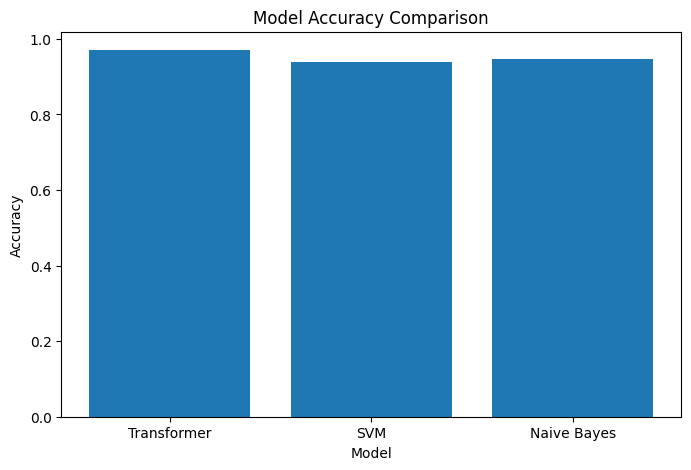

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    accuracy.keys(),
    accuracy.values()
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

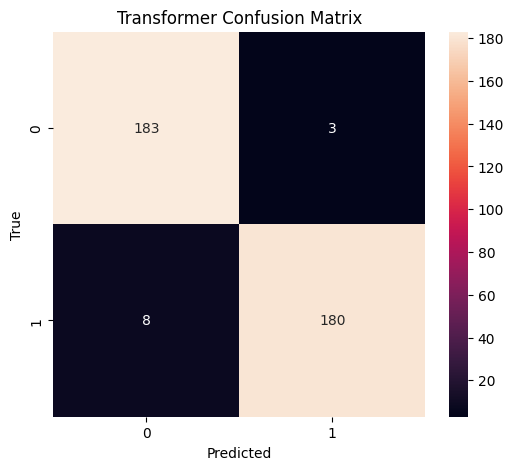

In [9]:
# Transformer Confusion Matrix
cm = confusion_matrix(
    comparison_df["true_label"],
    comparison_df["transformer_pred"]
)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

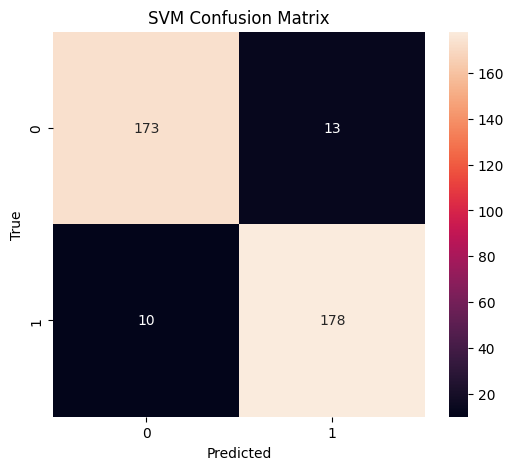

In [10]:
# SVM Confusion Matrix
cm = confusion_matrix(
    comparison_df["true_label"],
    comparison_df["svm_pred"]
)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

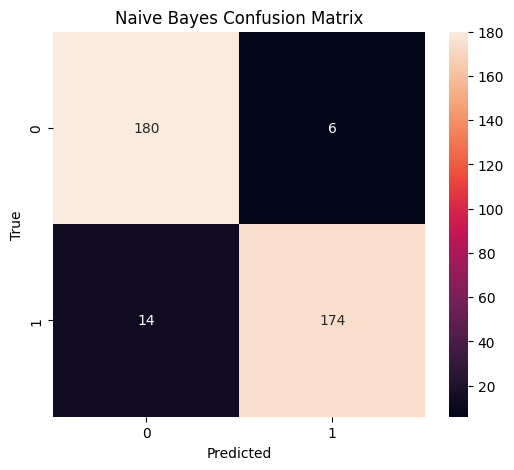

In [11]:

# Naive Bayes Confusion Matrix
cm = confusion_matrix(
    comparison_df["true_label"],
    comparison_df["nb_pred"]
)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [12]:
# Classification Reports
print("===== Transformer =====")
print(classification_report(
    comparison_df["true_label"],
    comparison_df["transformer_pred"]
))

print("===== SVM =====")
print(classification_report(
    comparison_df["true_label"],
    comparison_df["svm_pred"]
))

print("===== Naive Bayes =====")
print(classification_report(
    comparison_df["true_label"],
    comparison_df["nb_pred"]
))

===== Transformer =====
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       186
           1       0.98      0.96      0.97       188

    accuracy                           0.97       374
   macro avg       0.97      0.97      0.97       374
weighted avg       0.97      0.97      0.97       374

===== SVM =====
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       186
           1       0.93      0.95      0.94       188

    accuracy                           0.94       374
   macro avg       0.94      0.94      0.94       374
weighted avg       0.94      0.94      0.94       374

===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       186
           1       0.97      0.93      0.95       188

    accuracy                           0.95       374
   macro avg       0.95      0.95      0.95       374
weighted a

In [13]:
# Analyze cases where Transformer is correct but SVM is wrong
svm_transformer_cases = comparison_df[
    (comparison_df["svm_correct"] == False) &
    (comparison_df["transformer_correct"] == True)
]

print("Cases where Transformer correct but SVM wrong:")
svm_transformer_cases.head(10)[
    ["text","true_label","svm_pred","transformer_pred"]
]

Cases where Transformer correct but SVM wrong:


,text,true_label,svm_pred,transformer_pred
21,cooking alcohol healthy,0,1,0
49,ronaldo hits 961st goal al nassrs 30 rout al k...,1,0,1
81,controversy auditor general appointment trade ...,0,1,0
90,uganda police force recruiting polling constab...,0,1,0
102,government fail take action owo church massacre,0,1,0
126,ugandas opposition unites demand electoral ref...,1,0,1
131,international mens day celebrating men boys,0,1,0
142,trump write norway dissatisfaction nobel peace...,0,1,0
143,nup spokesperson waiswa mufumbiro released bail,0,1,0
170,research shows 1 8 students get adequate sleep,1,0,1


In [14]:
# Analyze cases where Transformer is correct but Naive Bayes is wrong
nb_transformer_cases = comparison_df[
    (comparison_df["nb_correct"] == False) &
    (comparison_df["transformer_correct"] == True)
]

print("Cases where Transformer correct but NB wrong:")
nb_transformer_cases.head(10)[
    ["text","true_label","nb_pred","transformer_pred"]
]

Cases where Transformer correct but NB wrong:


,text,true_label,nb_pred,transformer_pred
17,education foundation unity progress mubaje tel...,1,0,1
21,cooking alcohol healthy,0,1,0
49,ronaldo hits 961st goal al nassrs 30 rout al k...,1,0,1
81,controversy auditor general appointment trade ...,0,1,0
102,government fail take action owo church massacre,0,1,0
121,apps pimps algorithms technology advancing nig...,0,1,0
126,ugandas opposition unites demand electoral ref...,1,0,1
127,cou establish industrial park produce affordab...,1,0,1
170,research shows 1 8 students get adequate sleep,1,0,1
172,ugandas stateowned electricity distributor hiring,0,1,0


In [15]:
# Analyze cases where classical models succeed but Transformer fails
classical_better = comparison_df[
    (comparison_df["transformer_correct"] == False) &
    (
        (comparison_df["svm_correct"] == True) |
        (comparison_df["nb_correct"] == True)
    )
]

print("Cases where classical models succeed but Transformer fails:")
classical_better.head(10)[
    ["text","true_label","svm_pred","nb_pred","transformer_pred"]
]

Cases where classical models succeed but Transformer fails:


,text,true_label,svm_pred,nb_pred,transformer_pred
46,waziri wa afya atangaza kampeni ya chanjo ya s...,1,1,1,0
118,ayaj jjr gbogbo oun ti ni lati nipa aisan yii,0,0,0,1
146,ugandas finance ministry giving free grants en...,0,1,0,1
155,government approved free electricity ugandans ...,0,1,0,1
187,court upholds mulirires disqualification budio...,1,1,1,0
254,man named south africas police corruption prob...,1,1,1,0
368,exclusive judge bukirwa highstakes meeting mus...,1,1,1,0


In [16]:
# Analyze cases where all models fail
hard_samples = comparison_df[
    (comparison_df["svm_correct"] == False) &
    (comparison_df["nb_correct"] == False) &
    (comparison_df["transformer_correct"] == False)
]

print("Hard samples count:", len(hard_samples))

hard_samples.head(10)[
    ["text","true_label","svm_pred","nb_pred","transformer_pred"]
]

Hard samples count: 4


,text,true_label,svm_pred,nb_pred,transformer_pred
26,bukomansimbi road crash leaves two dead three ...,1,0,0,0
32,bad bunny makes history trump criticises terri...,1,0,0,0
324,evidence 5g technology spreads covid19 virus,1,0,0,0
338,ministry health confirms outbreak ebola kampala,1,0,0,0


In [17]:
# Save the merged comparison dataset for further analysis
comparison_df.to_csv(
    "../data/processed/model_comparison_results.csv",
    index=False
)

print("Comparison results saved.")

Comparison results saved.


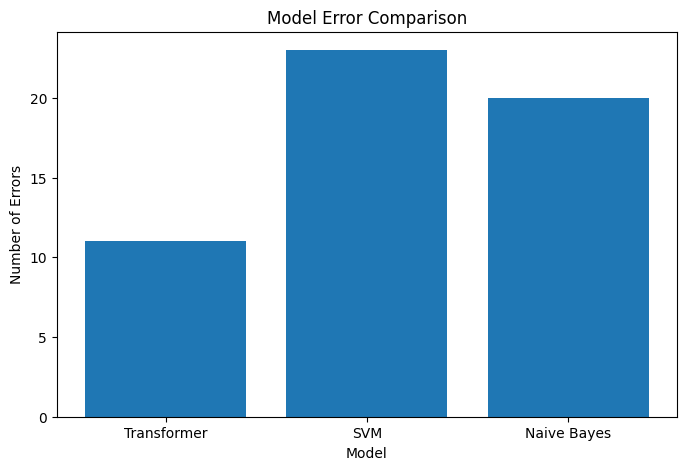

In [18]:
# Visualize error counts for each model
error_counts = [
    total - comparison_df["transformer_correct"].sum(),
    total - comparison_df["svm_correct"].sum(),
    total - comparison_df["nb_correct"].sum()
]

models = ["Transformer", "SVM", "Naive Bayes"]

plt.figure(figsize=(8,5))

plt.bar(models, error_counts)

plt.title("Model Error Comparison")
plt.ylabel("Number of Errors")
plt.xlabel("Model")

plt.show()